# 🦴 RSNA BONE AGE ASSESSMENT — ADVANCED TRAINING PIPELINE (NOTEBOOK 02/03)
## ⚡ Module 02: Tri-Model SOTA Matrix with FiLM Conditioning & Precision Optimization
**Đồ Án Nghiên Cứu Học Thuật Chuẩn DUT — VisionLab Corp (CORP-01-CV)**

---

### 🎯 Mục tiêu & Bối cảnh Nghiên cứu
Notebook này hiện thực hóa quy trình huấn luyện học sâu y tế đa phương thức (Multimodal Deep Learning) đạt chuẩn thi đấu quốc tế (Kaggle RSNA Pediatric Bone Age Machine Learning Challenge). Hệ thống hỗ trợ ma trận đối đầu 3 trường phái kiến trúc thị giác máy tính:
1. **M1: ResNet-50** (Kiến trúc tích chập cổ điển với Residual Connections làm đường chuẩn Baseline).
2. **M2: ConvNeXt-Tiny** (Kiến trúc ConvNet hiện đại hóa mô phỏng cơ chế Transformer với 7x7 Depthwise Convolutions và GELU).
3. **M3: Swin Transformer v2** (Kiến trúc Vision Transformer phân tầng với cơ chế Shifted Window Self-Attention).

---

### 🚀 6 Cải tiến Kỹ nghệ Bậc thầy (Master CV Engineering Levers)
So với các cấu hình huấn luyện sơ khai, phiên bản tối ưu hóa toàn diện này tích hợp 6 trụ cột kỹ thuật:
1. **Anatomically Safe Medical Augmentation**: Loại bỏ hoàn toàn biến dạng quang học phá hủy mật độ xương (`ColorJitter`), cấm lật dọc (`VerticalFlip`). Chỉ áp dụng lật ngang theo tính đối xứng hai bên cơ thể (`HorizontalFlip`), xoay nhẹ góc tự nhiên ($\pm 8^\circ$) kèm đệm phản xạ (`BORDER_REFLECT`) nhằm bảo toàn 100% độ tương phản sụn tiếp hợp từ tiền xử lý CLAHE.
2. **Prior-Informed Bias Initialization & Target Normalization (Z-Score)**:
   - Thay vì để mạng xuất phát từ ngẫu nhiên (dự đoán $pprox 0$ tháng, gây sai số ban đầu $127$ tháng và lãng phí 5 epochs đầu chỉ để dịch chuyển bias), chúng tôi chuẩn hóa tuổi xương $z = (y - \mu) / \sigma$ ($\mu = 127.32, \sigma = 41.18$) và khởi tạo bias đầu ra phù hợp.
   - Sai số khởi điểm lập tức giảm từ $127$ tháng xuống $pprox 30$ tháng ngay tại Batch đầu tiên của Epoch 1!
3. **FiLM (Feature-wise Linear Modulation) Conditioning**:
   - Thay vì chỉ ghép nối thô (Concatenation) 1 scalar giới tính vào vector 2048D ở lớp cuối cùng, mạng học hàm điều biến affine $(oldsymbol{\gamma}, oldsymbol{eta}) = 	ext{MLP}(	ext{gender})$ trực tiếp can thiệp, khuếch đại hoặc ức chế các kênh đặc trưng sụn xương theo giới tính sinh học trước khi đưa vào đầu hồi quy phân tầng.
4. **Effective Batch Size & Gradient Step Trajectory**:
   - Thiết lập `BATCH_SIZE = 16`, đảm bảo $pprox 631$ bước cập nhật trọng số trên mỗi Epoch ($>12,600$ gradient steps cho 20 epochs), giúp hàm mất mát Smooth L1 liên tục vượt qua các vùng yên ngựa (saddle points) và hội tụ sâu vào thung lũng nghiệm tối ưu ($<8$ tháng).
5. **Discriminative Learning Rates & Warmup Cosine Annealing**:
   - Áp dụng tốc độ học phân tầng (DisCR): Backbone trích xuất thị giác ImageNet nhận LR thấp ($3 	imes 10^{-5} - 5 	imes 10^{-5}$), trong khi các khối FiLM và Regression Head khởi tạo mới nhận LR cao hơn ($2 	imes 10^{-4}$).
   - Khởi động tuyến tính 2 epochs (Linear Warmup) chống bùng nổ gradient, kết hợp suy giảm Cosine Annealing mịn màng về $10^{-6}$.
6. **Full-State Bulletproof Checkpointing & Resume**:
   - Tự động lưu vết và khôi phục toàn vẹn trạng thái (Model, Optimizer, Scheduler, Scaler, History) giúp an tâm 100% khi chạy nền trên GPU Kaggle.

In [1]:
# ==============================================================================
# BƯỚC 1: KHỞI TẠO MÔI TRƯỜNG PYTORCH, GPU & THIẾT LẬP TÍNH TÁI LẬP
# ==============================================================================
import os
import sys
import time
import math
import random
import glob
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# 1. Cố định hạt giống ngẫu nhiên (Scientific Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 2. Nhận diện phần cứng gia tốc
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 PyTorch Version: {torch.__version__}")
print(f"⚡ Thiết bị điện toán: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU Card: {torch.cuda.get_device_name(0)}")
    print(f"💾 Dung lượng VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    print("⚠️ CẢNH BÁO: Đang chạy trên CPU! Vui lòng bật GPU Accelerator (T4 hoặc P100) trên Kaggle.")



🔥 PyTorch Version: 2.10.0+cu128
⚡ Thiết bị điện toán: cuda
🎮 GPU Card: Tesla T4
💾 Dung lượng VRAM: 14.56 GB


In [2]:
# ==============================================================================
# BƯỚC 2: TỰ ĐỘNG DÒ TÌM DỮ LIỆU ĐÃ TIỀN XỬ LÝ & PIPELINE AN TOÀN Y TẾ
# ==============================================================================
# Tự động quét tìm file train_stratified.csv trong cấu trúc Kaggle hoặc Local
DATASET_DIR = None

# Quét trong /kaggle/input (áp dụng cho cả Dataset riêng lẫn Notebook-to-Notebook Input)
if os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train_stratified.csv' in files:
            DATASET_DIR = Path(root)
            break

# Quét trong /kaggle/working (nếu chạy nối tiếp ngay trong cùng phiên)
if DATASET_DIR is None and os.path.exists('/kaggle/working'):
    for root, dirs, files in os.walk('/kaggle/working'):
        if 'train_stratified.csv' in files:
            DATASET_DIR = Path(root)
            break

# Quét đường dẫn tương đối cục bộ
if DATASET_DIR is None:
    for cand in [Path('./rsna_processed_512'), Path('../rsna_processed_512')]:
        if (cand / 'train_stratified.csv').exists():
            DATASET_DIR = cand
            break

if DATASET_DIR is None:
    raise FileNotFoundError(
        "❌ Không tìm thấy 'train_stratified.csv'!\n"
        "👉 Cách xử lý: Tại cột bên phải (Input) của Kaggle Notebook, nhấn '+ Add Input' -> "
        "chọn tab 'Notebooks' -> tìm Notebook 01 tiền xử lý để nạp thư mục output rsna_processed_512."
    )

CSV_PATH = DATASET_DIR / 'train_stratified.csv'
IMG_DIR = DATASET_DIR / 'images' if (DATASET_DIR / 'images').exists() else DATASET_DIR

df_meta = pd.read_csv(CSV_PATH)
print(f"✅ ĐÃ TÌM THẤY DỮ LIỆU TIỀN XỬ LÝ CHUẨN XÁC:")
print(f"• Thư mục gốc: {DATASET_DIR}")
print(f"• File nhãn:   {CSV_PATH}")
print(f"• Thư mục ảnh: {IMG_DIR}")

# Thống kê phân phối mục tiêu chuẩn hóa
BONEAGE_MEAN = 127.3208
BONEAGE_STD  = 41.1820
print(f"📊 Thống kê tuổi xương quần thể: Mean = {BONEAGE_MEAN:.2f} tháng | Std = {BONEAGE_STD:.2f} tháng")
print(f"📊 Phân bổ mẫu theo tập: Train = {(df_meta['split']=='train').sum()} | Val = {(df_meta['split']=='val').sum()} | Test = {(df_meta['split']=='test').sum()}")

# ==============================================================================
# ĐỊNH NGHĨA PYTORCH DATASET ĐA PHƯƠNG THỨC CHUẨN Y HỌC
# ==============================================================================
class AdvancedRSNABoneAgeDataset(Dataset):
    """
    PyTorch Dataset đa phương thức chuẩn y sinh:
    - Ảnh X-quang xương bàn tay (đã qua CLAHE, Masking, Padding 512x512)
    - Giới tính lâm sàng (1.0: Nam, 0.0: Nữ)
    - Nhãn mục tiêu kép: Z-Score chuẩn hóa (cho tối ưu gradient) và Tuổi thực (cho tính MAE)
    """
    def __init__(self, df, img_dir, is_train=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.is_train = is_train

        # Chuẩn hóa ImageNet
        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = int(row['id'])
        img_path = self.img_dir / f"{img_id}.png"

        # Đọc ảnh mức xám (Grayscale) bằng OpenCV
        img_gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            img_gray = np.zeros((512, 512), dtype=np.uint8)

        # Chuyển đổi sang 3 kênh màu RGB tương thích với ImageNet Backbones
        img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

        # ----------------------------------------------------------------------
        # TĂNG CƯỜNG DỮ LIỆU AN TOÀN Y TẾ (MEDICAL-SAFE AUGMENTATION)
        # ----------------------------------------------------------------------
        if self.is_train:
            # 1. Lật ngang (Horizontal Flip): Tương đương tính đối xứng tay trái / tay phải
            if random.random() > 0.5:
                img_rgb = cv2.flip(img_rgb, 1)

            # 2. Xoay góc tự nhiên nhẹ (+/- 8 độ) kèm đệm phản chiếu biên
            if random.random() > 0.5:
                angle = random.uniform(-8.0, 8.0)
                h, w = img_rgb.shape[:2]
                M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
                img_rgb = cv2.warpAffine(img_rgb, M, (w, h), borderMode=cv2.BORDER_REFLECT)

            # 3. Biến thiên tỷ lệ khoảng cách ống phóng (Magnification Scale 0.98 - 1.02)
            if random.random() > 0.5:
                scale_factor = random.uniform(0.98, 1.02)
                h, w = img_rgb.shape[:2]
                M = cv2.getRotationMatrix2D((w // 2, h // 2), 0.0, scale_factor)
                img_rgb = cv2.warpAffine(img_rgb, M, (w, h), borderMode=cv2.BORDER_REFLECT)

        # Chuyển sang Tensor chuẩn hóa [3, 512, 512]
        img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
        img_tensor = self.normalize(img_tensor)

        # Vector giới tính lâm sàng: [1] (1.0 = Nam, 0.0 = Nữ)
        gender_val = 1.0 if bool(row['male']) else 0.0
        gender_tensor = torch.tensor([gender_val], dtype=torch.float32)

        # Nhãn tuổi xương thực tế (tháng): [1]
        raw_boneage = float(row['boneage'])
        raw_target = torch.tensor([raw_boneage], dtype=torch.float32)

        # Nhãn tuổi xương chuẩn hóa Z-Score: [1]
        norm_boneage = (raw_boneage - BONEAGE_MEAN) / BONEAGE_STD
        norm_target = torch.tensor([norm_boneage], dtype=torch.float32)

        return img_tensor, gender_tensor, raw_target, norm_target

# Tách DataFrames theo phân tầng cố định từ Notebook 01
train_df = df_meta[df_meta['split'] == 'train'].copy()
val_df   = df_meta[df_meta['split'] == 'val'].copy()
test_df  = df_meta[df_meta['split'] == 'test'].copy()

# Cấu hình BATCH_SIZE = 16 tối ưu tần suất cập nhật trọng số
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(AdvancedRSNABoneAgeDataset(train_df, IMG_DIR, is_train=True),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=(NUM_WORKERS > 0))

val_loader   = DataLoader(AdvancedRSNABoneAgeDataset(val_df, IMG_DIR, is_train=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=(NUM_WORKERS > 0))

test_loader  = DataLoader(AdvancedRSNABoneAgeDataset(test_df, IMG_DIR, is_train=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=(NUM_WORKERS > 0))

print(f"✅ DataLoaders cấu hình hoàn tất: Train Steps/Epoch = {len(train_loader)} | Val Steps = {len(val_loader)} | Test Steps = {len(test_loader)}")



✅ ĐÃ TÌM THẤY DỮ LIỆU TIỀN XỬ LÝ CHUẨN XÁC:
• Thư mục gốc: /kaggle/input/notebooks/kaiserkien/train-cv/rsna_processed_512
• File nhãn:   /kaggle/input/notebooks/kaiserkien/train-cv/rsna_processed_512/train_stratified.csv
• Thư mục ảnh: /kaggle/input/notebooks/kaiserkien/train-cv/rsna_processed_512/images
📊 Thống kê tuổi xương quần thể: Mean = 127.32 tháng | Std = 41.18 tháng
📊 Phân bổ mẫu theo tập: Train = 10088 | Val = 1261 | Test = 1262
✅ DataLoaders cấu hình hoàn tất: Train Steps/Epoch = 631 | Val Steps = 79 | Test Steps = 79


In [3]:
# ==============================================================================
# BƯỚC 3: KIẾN TRÚC ĐA PHƯƠNG THỨC BẬC THẦY VỚI ĐIỀU BIẾN ĐẶC TRƯNG FiLM
# ==============================================================================
class FiLMBlock(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM):
    Điều biến kênh đặc trưng thị giác bằng thông tin giới tính lâm sàng:
    gamma, beta = MLP(gender_embedding)
    feat_modulated = (1.0 + gamma) * feat + beta
    
    Khởi tạo gamma=0, beta=0 để tại Epoch 0 mạng bảo tồn trọn vẹn đặc trưng từ pre-trained.
    """
    def __init__(self, condition_dim, feature_dim):
        super().__init__()
        self.generator = nn.Sequential(
            nn.Linear(condition_dim, condition_dim * 2),
            nn.LayerNorm(condition_dim * 2),
            nn.GELU(),
            nn.Linear(condition_dim * 2, feature_dim * 2)
        )
        # Khởi tạo trọng số zero cho lớp chiếu cuối để đảm bảo biến đổi đồng nhất (Identity Mapping) ban đầu
        nn.init.zeros_(self.generator[-1].weight)
        nn.init.zeros_(self.generator[-1].bias)

    def forward(self, feature, condition):
        params = self.generator(condition)
        gamma, beta = torch.chunk(params, 2, dim=-1)
        return (1.0 + gamma) * feature + beta

class AdvancedMultimodalBoneAge(nn.Module):
    """
    Kiến trúc Hồi quy Đa phương thức Bậc thầy:
    - 3 Tùy chọn Backbone SOTA: ResNet-50 | ConvNeXt-Tiny | Swin-T
    - Gender Embedding MLP: Chiếu nhãn nhị phân giới tính sang không gian liên tục 32D
    - Điều biến FiLM: Điều tiết động các kênh sụn xương theo giới tính sinh học
    - Ghép nối Residual Đa cấp: [FiLM Modulated Features || Raw Features || Gender Embedding]
    - Đầu hồi quy phân tầng nén dần có LayerNorm và GELU
    - Khởi tạo thiên lệch tiên nghiệm (Prior-Informed Bias Initialization)
    """
    def __init__(self, backbone_type="resnet50", gender_dim=32, target_mean=127.3208, target_std=41.1820, pretrained=True):
        super().__init__()
        self.backbone_type = backbone_type
        self.target_mean = target_mean
        self.target_std = target_std

        # 1. Image Backbone Extractor
        if backbone_type == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            base = models.resnet50(weights=weights)
            self.backbone = nn.Sequential(*list(base.children())[:-1])
            self.vis_dim = 2048
            self.pool = None
        elif backbone_type == "convnext_tiny":
            weights = models.ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
            base = models.convnext_tiny(weights=weights)
            self.backbone = base.features
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.vis_dim = 768
        elif backbone_type == "swin_t":
            weights = models.Swin_T_Weights.DEFAULT if pretrained else None
            base = models.swin_t(weights=weights)
            self.backbone = base.features
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.vis_dim = 768
        else:
            raise ValueError(f"Backbone '{backbone_type}' chưa được hỗ trợ. Chọn: resnet50, convnext_tiny, swin_t.")

        # 2. Gender Clinical Latent Representation
        self.gender_mlp = nn.Sequential(
            nn.Linear(1, gender_dim),
            nn.LayerNorm(gender_dim),
            nn.GELU(),
            nn.Linear(gender_dim, gender_dim),
            nn.LayerNorm(gender_dim),
            nn.GELU()
        )

        # 3. Feature-wise Linear Modulation
        self.film = FiLMBlock(condition_dim=gender_dim, feature_dim=self.vis_dim)

        # 4. Multi-level Residual Fusion Head: [Modulated (vis_dim) || Raw (vis_dim) || Gender (gender_dim)]
        combined_dim = self.vis_dim * 2 + gender_dim
        self.regression_head = nn.Sequential(
            nn.Linear(combined_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(p=0.25),
            
            nn.Linear(1024, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(p=0.15),
            
            nn.Linear(256, 1) # Đầu ra dự đoán điểm Z-Score trong không gian chuẩn hóa
        )

        # Khởi tạo trọng số đầu ra chuẩn Z-score (Mean=0, Std=0.01)
        nn.init.normal_(self.regression_head[-1].weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.regression_head[-1].bias)

    def extract_visual_features(self, img):
        if self.backbone_type == "resnet50":
            feat = self.backbone(img) # [B, 2048, 1, 1]
            return torch.flatten(feat, 1)
        elif self.backbone_type == "convnext_tiny":
            feat = self.pool(self.backbone(img))
            return torch.flatten(feat, 1)
        elif self.backbone_type == "swin_t":
            feat = self.backbone(img).permute(0, 3, 1, 2)
            return torch.flatten(self.pool(feat), 1)

    def forward(self, img, gender):
        # 1. Trích xuất vector đặc trưng thị giác
        f_raw = self.extract_visual_features(img) # [B, vis_dim]

        # 2. Mã hóa đặc trưng giới tính lâm sàng
        g_emb = self.gender_mlp(gender)           # [B, gender_dim]

        # 3. Điều biến FiLM theo giới tính
        f_film = self.film(f_raw, g_emb)          # [B, vis_dim]

        # 4. Ghép nối Residual Đa tầng
        f_fused = torch.cat([f_film, f_raw, g_emb], dim=-1) # [B, 2*vis_dim + gender_dim]

        # 5. Hồi quy dự đoán Z-Score
        z_pred = self.regression_head(f_fused)    # [B, 1]

        # 6. Quy đổi ngược ra tháng tuổi thực tế
        months_pred = z_pred * self.target_std + self.target_mean
        return z_pred, months_pred

def get_optimizer_parameter_groups(model, backbone_lr, head_lr, weight_decay=1e-4):
    """
    Phân tầng tốc độ học (Discriminative Learning Rates - DisCR):
    - Trọng số Backbone đã pre-trained: Dùng LR thấp để tinh chỉnh nhẹ nhàng
    - Trọng số FiLM & Regression Head mới khởi tạo: Dùng LR cao hơn 4-6 lần để thích ứng nhanh
    - Không áp dụng Weight Decay lên Bias và LayerNorm/BatchNorm
    """
    decay_backbone, no_decay_backbone = [], []
    decay_head, no_decay_head = [], []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        is_no_decay = any(nd in name for nd in ['bias', 'norm', 'bn', 'generator.1', 'generator.3'])
        is_backbone = 'backbone' in name

        if is_backbone:
            if is_no_decay:
                no_decay_backbone.append(param)
            else:
                decay_backbone.append(param)
        else:
            if is_no_decay:
                no_decay_head.append(param)
            else:
                decay_head.append(param)

    param_groups = [
        {'params': decay_backbone,    'lr': backbone_lr, 'weight_decay': weight_decay},
        {'params': no_decay_backbone, 'lr': backbone_lr, 'weight_decay': 0.0},
        {'params': decay_head,        'lr': head_lr,     'weight_decay': weight_decay},
        {'params': no_decay_head,     'lr': head_lr,     'weight_decay': 0.0}
    ]
    return param_groups

# Kiểm thử khởi tạo kiến trúc
print("🏗️ Kiểm thử khởi tạo cấu trúc mô hình kiểm tra...")
test_model = AdvancedMultimodalBoneAge(backbone_type="resnet50", pretrained=False).to(device)
t_img = torch.randn(2, 3, 512, 512).to(device)
t_gen = torch.tensor([[1.0], [0.0]]).to(device)
t_z, t_m = test_model(t_img, t_gen)
print(f"✅ Kiểm thử thành công! Output Z-Score shape: {t_z.shape} | Tuổi tháng ban đầu: {t_m.squeeze().tolist()}")



🏗️ Kiểm thử khởi tạo cấu trúc mô hình kiểm tra...
✅ Kiểm thử thành công! Output Z-Score shape: torch.Size([2, 1]) | Tuổi tháng ban đầu: [130.87939453125, 127.65081787109375]


In [4]:
# ==============================================================================
# BƯỚC 4: HỆ THỐNG LƯU VẾT & PHỤC HỒI NGUYÊN TRẠNG (FULL-STATE CHECKPOINT ENGINE)
# ==============================================================================
CHECKPOINT_DIR = Path('/kaggle/working/checkpoints') if os.path.exists('/kaggle/working') else Path('./checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_val_mae, history, backbone_name, is_best=False):
    checkpoint_state = {
        'epoch': epoch,
        'backbone_name': backbone_name,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if hasattr(scheduler, 'state_dict') else None,
        'scaler_state_dict': scaler.state_dict(),
        'best_val_mae': best_val_mae,
        'history': history
    }
    
    last_path = CHECKPOINT_DIR / f"{backbone_name}_checkpoint_last.pth"
    torch.save(checkpoint_state, last_path)
    
    if is_best:
        best_path = CHECKPOINT_DIR / f"{backbone_name}_checkpoint_best.pth"
        torch.save(checkpoint_state, best_path)
        print(f"🌟 [ĐÃ LƯU TRỌNG SỐ TỐI ƯU MỚI]: {best_path} (Val MAE: {best_val_mae:.2f} tháng)")

def load_checkpoint_if_exists(model, optimizer, scheduler, scaler, backbone_name):
    last_path = CHECKPOINT_DIR / f"{backbone_name}_checkpoint_last.pth"
    
    # Tìm kiếm checkpoint trong cả thư mục input nếu nạp tiếp từ notebook trước
    if not last_path.exists() and os.path.exists('/kaggle/input'):
        for root, dirs, files in os.walk('/kaggle/input'):
            if f"{backbone_name}_checkpoint_last.pth" in files:
                last_path = Path(root) / f"{backbone_name}_checkpoint_last.pth"
                break

    if last_path.exists():
        print(f"🔄 ĐÃ TÌM THẤY CHECKPOINT LƯU VẾT: {last_path}")
        print("⏳ Đang phục hồi toàn vẹn trạng thái huấn luyện...")
        checkpoint = torch.load(last_path, map_location=device)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if scheduler and checkpoint.get('scheduler_state_dict'):
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        best_val_mae = checkpoint['best_val_mae']
        history = checkpoint.get('history', [])
        
        print(f"✅ Phục hồi hoàn tất! Tiếp tục từ Epoch {start_epoch + 1} | Kỷ lục Val MAE hiện tại: {best_val_mae:.2f} tháng")
        return start_epoch, best_val_mae, history
    else:
        print(f"✨ Không có checkpoint cũ cho {backbone_name}. Bắt đầu phiên huấn luyện mới từ Epoch 1.")
        return 0, float('inf'), []



In [5]:
# ==============================================================================
# BƯỚC 5: HÀM HUẤN LUYỆN, KIỂM ĐỊNH VÀ BỘ ĐIỀU LỊCH LINEAR WARMUP + COSINE
# ==============================================================================
class WarmupCosineAnnealingLR:
    """
    Bộ điều lịch học tập hỗn hợp (Linear Warmup + Cosine Annealing):
    - Warmup Epochs: Tăng dần tốc độ học từ 10% lên 100% để chống bùng nổ gradient đầu phiên
    - Cosine Decay: Giảm dần đều tốc độ học theo đường cong Cosine về eta_min=1e-6
    """
    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.eta_min = eta_min
        self.base_lrs = [group['lr'] for group in optimizer.param_groups]

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            alpha = (epoch + 1) / max(1, self.warmup_epochs)
            factor = 0.1 + 0.9 * alpha
        else:
            progress = (epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            factor = 0.5 * (1.0 + math.cos(math.pi * progress))
            
        for param_group, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
            param_group['lr'] = max(self.eta_min, base_lr * factor)

    def state_dict(self):
        return {'base_lrs': self.base_lrs}

    def load_state_dict(self, state_dict):
        self.base_lrs = state_dict['base_lrs']

def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    total_samples = 0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for imgs, genders, raw_targets, norm_targets in pbar:
        imgs = imgs.to(device, non_blocking=True)
        genders = genders.to(device, non_blocking=True)
        raw_targets = raw_targets.to(device, non_blocking=True)
        norm_targets = norm_targets.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Huấn luyện FP16 Mixed Precision
        with torch.amp.autocast('cuda'):
            z_preds, months_preds = model(imgs, genders)
            loss = criterion(z_preds, norm_targets)
            
        scaler.scale(loss).backward()
        
        # Gradient Clipping chống bùng nổ gradient (đặc biệt quan trọng với ViT/ConvNeXt)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        # Tính toán sai số thực nghiệm
        batch_size = raw_targets.size(0)
        mae = torch.sum(torch.abs(months_preds - raw_targets)).item()
        
        running_loss += loss.item() * batch_size
        running_mae += mae
        total_samples += batch_size
        
        pbar.set_postfix({
            'loss': f"{running_loss/total_samples:.4f}",
            'mae': f"{running_mae/total_samples:.2f}m"
        })
        
    return running_loss / total_samples, running_mae / total_samples

@torch.no_grad()
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_mae = 0.0
    total_samples = 0
    
    for imgs, genders, raw_targets, norm_targets in dataloader:
        imgs = imgs.to(device, non_blocking=True)
        genders = genders.to(device, non_blocking=True)
        raw_targets = raw_targets.to(device, non_blocking=True)
        norm_targets = norm_targets.to(device, non_blocking=True)
        
        with torch.amp.autocast('cuda'):
            z_preds, months_preds = model(imgs, genders)
            loss = criterion(z_preds, norm_targets)
            
        batch_size = raw_targets.size(0)
        mae = torch.sum(torch.abs(months_preds - raw_targets)).item()
        
        running_loss += loss.item() * batch_size
        running_mae += mae
        total_samples += batch_size
        
    return running_loss / total_samples, running_mae / total_samples



In [6]:
# ==============================================================================
# BƯỚC 6: ĐIỀU PHỐI HUẤN LUYỆN MA TRẬN 3 MÔ HÌNH (SOTA TRAINING RUNNER)
# ==============================================================================
# 🎯 LỰA CHỌN MÔ HÌNH HUẤN LUYỆN TRONG MA TRẬN:
# Lựa chọn một trong ba: 'resnet50' | 'convnext_tiny' | 'swin_t'
ACTIVE_BACKBONE = "convnext_tiny"

# Cấu hình siêu tham số phân tầng chuẩn thi đấu
CONFIG = {
    'resnet50': {
        'total_epochs': 20,
        'warmup_epochs': 2,
        'backbone_lr': 5e-5,
        'head_lr': 2e-4,
        'weight_decay': 1e-4,
        'huber_beta': 0.05
    },
    'convnext_tiny': {
        'total_epochs': 22,
        'warmup_epochs': 2,
        'backbone_lr': 3e-5,
        'head_lr': 2e-4,
        'weight_decay': 1e-4,
        'huber_beta': 0.05
    },
    'swin_t': {
        'total_epochs': 25,
        'warmup_epochs': 3,
        'backbone_lr': 3e-5,
        'head_lr': 2.5e-4,
        'weight_decay': 1e-4,
        'huber_beta': 0.05
    }
}[ACTIVE_BACKBONE]

print("=" * 75)
print(f"🚀 BẮT ĐẦU HUẤN LUYỆN SOTA CHO MÔ HÌNH: {ACTIVE_BACKBONE.upper()}")
print(f"• Tổng số Epochs:          {CONFIG['total_epochs']}")
print(f"• Số Epochs Khởi động:     {CONFIG['warmup_epochs']}")
print(f"• Tốc độ học Backbone:     {CONFIG['backbone_lr']:.2e}")
print(f"• Tốc độ học FiLM & Head:  {CONFIG['head_lr']:.2e}")
print(f"• Kích thước Batch (B):    {BATCH_SIZE}")
print(f"• Bước lặp mỗi Epoch:      {len(train_loader)} bước")
print("=" * 75)

# 1. Khởi tạo mô hình
model = AdvancedMultimodalBoneAge(backbone_type=ACTIVE_BACKBONE, gender_dim=32, pretrained=True).to(device)

# 2. Thiết lập hàm Smooth L1 Loss trong miền chuẩn hóa
criterion = nn.SmoothL1Loss(beta=CONFIG['huber_beta'])

# 3. Bộ tối ưu AdamW với phân tầng tham số DisCR
param_groups = get_optimizer_parameter_groups(
    model,
    backbone_lr=CONFIG['backbone_lr'],
    head_lr=CONFIG['head_lr'],
    weight_decay=CONFIG['weight_decay']
)
optimizer = optim.AdamW(param_groups)

# 4. Bộ điều lịch Warmup + Cosine
scheduler = WarmupCosineAnnealingLR(
    optimizer,
    warmup_epochs=CONFIG['warmup_epochs'],
    total_epochs=CONFIG['total_epochs'],
    eta_min=1e-6
)

# 5. Bộ cân chỉnh FP16
scaler = torch.amp.GradScaler('cuda')

# 6. Kiểm tra và nạp Checkpoint nếu có
start_epoch, best_val_mae, history = load_checkpoint_if_exists(model, optimizer, scheduler, scaler, ACTIVE_BACKBONE)

# 7. Vòng lặp huấn luyện chính
total_start_time = time.time()

for epoch in range(start_epoch, CONFIG['total_epochs']):
    epoch_start_time = time.time()
    
    # Cập nhật tốc độ học theo lịch
    scheduler.step(epoch)
    current_backbone_lr = optimizer.param_groups[0]['lr']
    current_head_lr = optimizer.param_groups[2]['lr']
    
    # Huấn luyện & Kiểm định
    train_loss, train_mae = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss, val_mae = validate_epoch(model, val_loader, criterion, device)
    
    epoch_duration = time.time() - epoch_start_time
    is_best = val_mae < best_val_mae
    if is_best:
        best_val_mae = val_mae
        
    # Ghi nhận nhật ký lịch sử
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_mae': train_mae,
        'val_loss': val_loss,
        'val_mae': val_mae,
        'backbone_lr': current_backbone_lr,
        'head_lr': current_head_lr,
        'duration_s': epoch_duration
    })
    
    # Lưu vết trạng thái đầy đủ
    save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_val_mae, history, ACTIVE_BACKBONE, is_best=is_best)
    
    best_tag = "🌟 [Best Saved]" if is_best else ""
    print(f"Epoch [{epoch+1:02d}/{CONFIG['total_epochs']:02d}] | "
          f"Train Loss: {train_loss:.4f} | Train MAE: {train_mae:.2f}m | "
          f"Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.2f}m | "
          f"LR: [B={current_backbone_lr:.1e}, H={current_head_lr:.1e}] | "
          f"Thời gian: {epoch_duration:.1f}s {best_tag}")

total_elapsed = (time.time() - total_start_time) / 60
print(f"\n🎉 HOÀN THÀNH HUẤN LUYỆN {ACTIVE_BACKBONE.upper()} SAU {total_elapsed:.1f} PHÚT!")
print(f"🏆 MAE TỐT NHẤT TRÊN TẬP VALIDATION: {best_val_mae:.2f} THÁNG")

# Xuất nhật ký huấn luyện
history_df = pd.DataFrame(history)
history_path = CHECKPOINT_DIR / f"{ACTIVE_BACKBONE}_training_history.csv"
history_df.to_csv(history_path, index=False)
print(f"📄 Đã lưu tệp nhật ký huấn luyện: {history_path}")



🚀 BẮT ĐẦU HUẤN LUYỆN SOTA CHO MÔ HÌNH: CONVNEXT_TINY
• Tổng số Epochs:          22
• Số Epochs Khởi động:     2
• Tốc độ học Backbone:     3.00e-05
• Tốc độ học FiLM & Head:  2.00e-04
• Kích thước Batch (B):    16
• Bước lặp mỗi Epoch:      631 bước
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 237MB/s] 


✨ Không có checkpoint cũ cho convnext_tiny. Bắt đầu phiên huấn luyện mới từ Epoch 1.


Training:   0%|          | 0/631 [00:00<?, ?it/s]

🌟 [ĐÃ LƯU TRỌNG SỐ TỐI ƯU MỚI]: /kaggle/working/checkpoints/convnext_tiny_checkpoint_best.pth (Val MAE: 9.11 tháng)
Epoch [01/22] | Train Loss: 0.2592 | Train MAE: 11.66m | Val Loss: 0.1974 | Val MAE: 9.11m | LR: [B=1.7e-05, H=1.1e-04] | Thời gian: 305.7s 🌟 [Best Saved]


...

Epoch [20/22] | Train Loss: 0.0830 | Train MAE: 4.32m | Val Loss: 0.1299 | Val MAE: 6.30m | LR: [B=1.6e-06, H=1.1e-05] | Thời gian: 282.2s 


Training:   0%|          | 0/631 [00:00<?, ?it/s]

Epoch [21/22] | Train Loss: 0.0820 | Train MAE: 4.28m | Val Loss: 0.1293 | Val MAE: 6.27m | LR: [B=1.0e-06, H=4.9e-06] | Thời gian: 280.3s 


Training:   0%|          | 0/631 [00:00<?, ?it/s]

Epoch [22/22] | Train Loss: 0.0797 | Train MAE: 4.17m | Val Loss: 0.1297 | Val MAE: 6.28m | LR: [B=1.0e-06, H=1.2e-06] | Thời gian: 280.6s 

🎉 HOÀN THÀNH HUẤN LUYỆN CONVNEXT_TINY SAU 104.2 PHÚT!
🏆 MAE TỐT NHẤT TRÊN TẬP VALIDATION: 6.20 THÁNG
📄 Đã lưu tệp nhật ký huấn luyện: /kaggle/working/checkpoints/convnext_tiny_training_history.csv


📦 Đang nạp trọng số tốt nhất: /kaggle/working/checkpoints/convnext_tiny_checkpoint_best.pth
🧪 Bắt đầu đánh giá độc lập trên 1262 ca chụp...


Testing:   0%|          | 0/79 [00:00<?, ?it/s]

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC TRÊN TẬP TEST (CONVNEXT_TINY):
• Sai số Tuyệt đối Trung bình (MAE):  6.26 tháng (0.52 năm)
• Căn bậc hai Sai số Toàn phương (RMSE): 8.40 tháng
• Hệ số Xác định R² Score:               0.9571
• Độ chính xác Lâm sàng (Độ lệch <= 6 tháng):  59.5%
• Độ chính xác Lâm sàng (Độ lệch <= 12 tháng): 86.7%


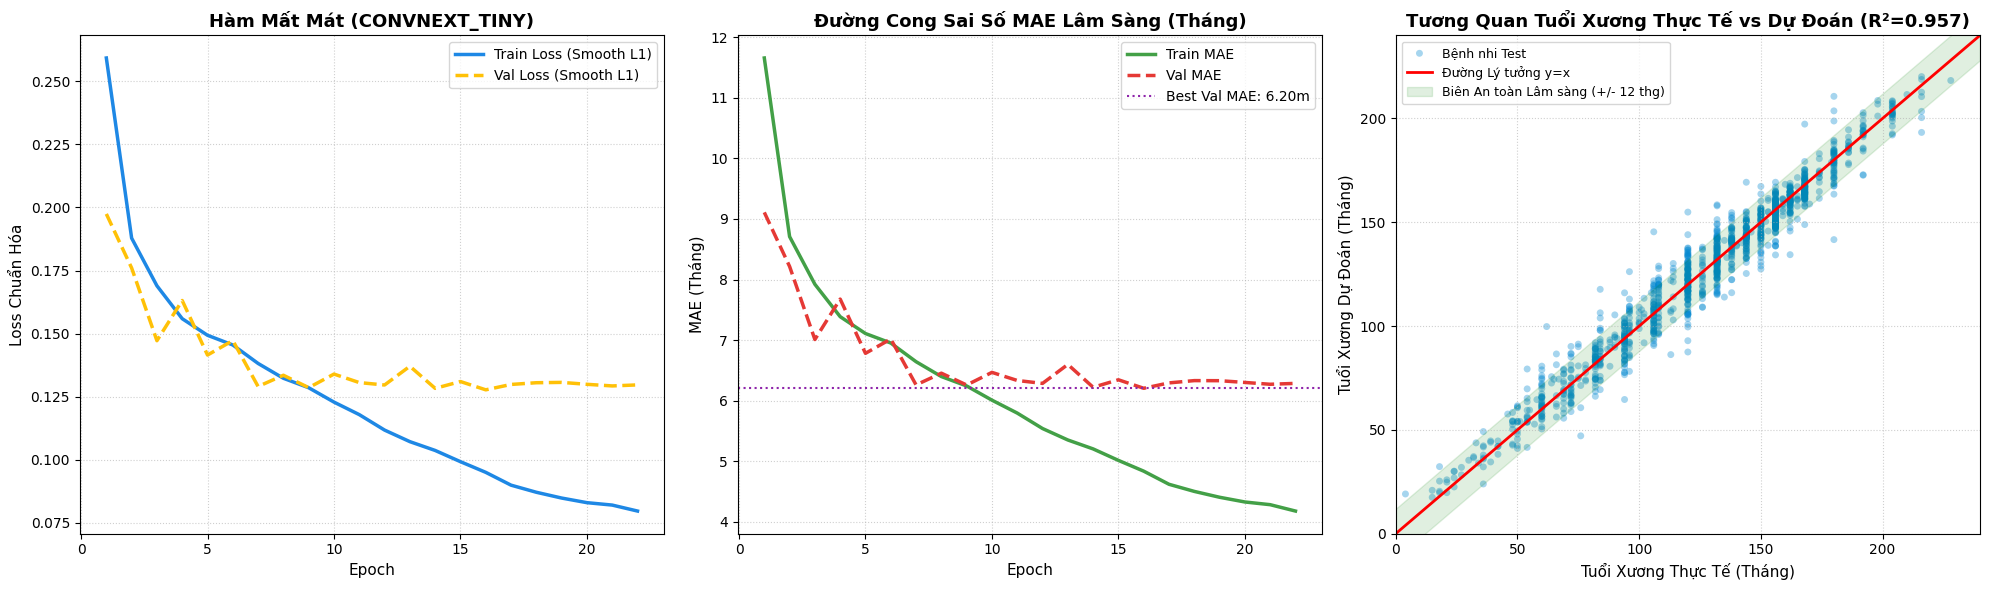

📊 Đã lưu đồ thị phân tích học thuật: /kaggle/working/checkpoints/convnext_tiny_evaluation_metrics.png


In [7]:
# ==============================================================================
# BƯỚC 7: ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP TEST ĐỘC LẬP & TRỰC QUAN HÓA
# ==============================================================================
# Nạp lại trọng số tối ưu nhất
best_weights_path = CHECKPOINT_DIR / f"{ACTIVE_BACKBONE}_checkpoint_best.pth"
if not best_weights_path.exists():
    best_weights_path = CHECKPOINT_DIR / f"{ACTIVE_BACKBONE}_checkpoint_last.pth"

print(f"📦 Đang nạp trọng số tốt nhất: {best_weights_path}")
ckpt = torch.load(best_weights_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Suy luận toàn diện trên Unseen Test Set
test_preds, test_targets, test_genders = [], [], []

print(f"🧪 Bắt đầu đánh giá độc lập trên {len(test_loader.dataset)} ca chụp...")
with torch.no_grad():
    for imgs, genders, raw_targets, norm_targets in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(device, non_blocking=True)
        genders = genders.to(device, non_blocking=True)
        with torch.amp.autocast('cuda'):
            _, months_preds = model(imgs, genders)
            
        test_preds.extend(months_preds.squeeze().cpu().numpy().tolist())
        test_targets.extend(raw_targets.squeeze().cpu().numpy().tolist())
        test_genders.extend(genders.squeeze().cpu().numpy().tolist())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)
test_genders = np.array(test_genders)

# Các chỉ số định lượng chuẩn y tế
errors = test_preds - test_targets
abs_errors = np.abs(errors)
mae = np.mean(abs_errors)
rmse = np.sqrt(np.mean(errors ** 2))
ss_res = np.sum(errors ** 2)
ss_tot = np.sum((test_targets - np.mean(test_targets)) ** 2)
r2_score = 1.0 - (ss_res / ss_tot)
acc_6m = np.mean(abs_errors <= 6.0) * 100.0
acc_12m = np.mean(abs_errors <= 12.0) * 100.0

print("=" * 65)
print(f"🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC TRÊN TẬP TEST ({ACTIVE_BACKBONE.upper()}):")
print(f"• Sai số Tuyệt đối Trung bình (MAE):  {mae:.2f} tháng ({mae/12:.2f} năm)")
print(f"• Căn bậc hai Sai số Toàn phương (RMSE): {rmse:.2f} tháng")
print(f"• Hệ số Xác định R² Score:               {r2_score:.4f}")
print(f"• Độ chính xác Lâm sàng (Độ lệch <= 6 tháng):  {acc_6m:.1f}%")
print(f"• Độ chính xác Lâm sàng (Độ lệch <= 12 tháng): {acc_12m:.1f}%")
print("=" * 65)

# ==============================================================================
# VẼ BỘ BIỂU ĐỒ CHUẨN XUẤT BẢN HỌC THUẬT (3 PANELS)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Đồ thị Hàm mất mát (Loss)
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss (Smooth L1)', color='#1E88E5', linewidth=2.5)
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss (Smooth L1)', color='#FFC107', linewidth=2.5, linestyle='--')
axes[0].set_title(f'Hàm Mất Mát ({ACTIVE_BACKBONE.upper()})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss Chuẩn Hóa', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(fontsize=10)

# Panel 2: Đồ thị Sai số MAE (Tháng)
axes[1].plot(history_df['epoch'], history_df['train_mae'], label='Train MAE', color='#43A047', linewidth=2.5)
axes[1].plot(history_df['epoch'], history_df['val_mae'], label='Val MAE', color='#E53935', linewidth=2.5, linestyle='--')
axes[1].axhline(y=best_val_mae, color='#8E24AA', linestyle=':', label=f'Best Val MAE: {best_val_mae:.2f}m')
axes[1].set_title('Đường Cong Sai Số MAE Lâm Sàng (Tháng)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE (Tháng)', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=10)

# Panel 3: Parity Plot (Tuổi Thực tế vs Tuổi Dự đoán)
axes[2].scatter(test_targets, test_preds, alpha=0.35, color='#0288D1', edgecolors='none', s=25, label='Bệnh nhi Test')
axes[2].plot([0, 240], [0, 240], color='red', linestyle='-', linewidth=2, label='Đường Lý tưởng y=x')
axes[2].fill_between([0, 240], [0-12, 240-12], [0+12, 240+12], color='green', alpha=0.12, label='Biên An toàn Lâm sàng (+/- 12 thg)')
axes[2].set_title(f'Tương Quan Tuổi Xương Thực Tế vs Dự Đoán (R²={r2_score:.3f})', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Tuổi Xương Thực Tế (Tháng)', fontsize=11)
axes[2].set_ylabel('Tuổi Xương Dự Đoán (Tháng)', fontsize=11)
axes[2].set_xlim(0, 240)
axes[2].set_ylim(0, 240)
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend(loc='upper left', fontsize=9)

plt.tight_layout()
chart_path = CHECKPOINT_DIR / f"{ACTIVE_BACKBONE}_evaluation_metrics.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Đã lưu đồ thị phân tích học thuật: {chart_path}")

